## Célula 1 — Leitura crua e catalogação dos *light curves* do SPARC4

Varre recursivamente a pasta de dados atrás de todos os `*_lc.fits` e abre cada um **sem filtrar, ordenar ou combinar nada**: as colunas saem como o *pipeline* gravou. Do nome do arquivo extrai o **canal/banda** (`_s4c1..4_` → g, r, i, z) e o **feixe** (`S`, `N`, `S+N`, `S-N` — o SPARC4 é polarimétrico e separa dois feixes).

Cada extensão do FITS corresponde a uma **abertura fotométrica** (`APRADIUS`) e vira uma entrada em `aper`, com colunas, vetor de tempos, nº de fontes e **cadência** (mediana dos intervalos, em s).

A tabela impressa é o **inventário** da noite: o que existe, em que banda, com quantos pontos, qual cadência e o intervalo UTC de cada série. Etapa de inspeção — nada de ciência ainda.

In [1]:
# ═══ leitura crua dos LC do SPARC4 ─ só abre o que existe e cataloga ════════
import glob
import os
import re

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}

arquivos = sorted(glob.glob(os.path.join(BASE, "**", "*_lc.fits"), recursive=True))


def le_lc(arq):
    """Lê um arquivo _lc.fits inteiro: todas as extensões, todas as colunas.

    Nada é filtrado, ordenado ou combinado — as colunas saem como o pipeline
    gravou. Cada extensão vira uma entrada em `aper`, indexada pelo APRADIUS
    do header (ou pelo número da extensão, se o header não trouxer o campo).
    """
    nome = os.path.basename(arq)
    ch   = re.search(r"_s4c(\d)_", nome)
    feix = re.search(r"_(S\+N|S-N|S|N)_lc\.fits$", nome)

    reg = dict(arquivo=nome, caminho=arq, noite=os.path.basename(os.path.dirname(arq)),
               canal=int(ch.group(1)) if ch else None,
               banda=BANDAS.get(int(ch.group(1))) if ch else None,
               feixe=feix.group(1) if feix else None, aper={})

    with fits.open(arq) as h:
        reg["header"] = dict(h[0].header)
        for i, ext in enumerate(h[1:], start=1):
            d = ext.data
            if d is None:
                continue
            cols = {c: np.asarray(d[c]) for c in d.columns.names}
            r = ext.header.get("APRADIUS", i)
            t = np.unique(np.asarray(cols["TIME"], float)) if "TIME" in cols else np.array([])
            reg["aper"][r] = dict(ext=i, colunas=list(cols), n_linhas=len(d), dados=cols,
                                  t=t, n_fontes=np.unique(cols["SRCINDEX"]).size if "SRCINDEX" in cols else 0,
                                  cad=float(np.median(np.diff(t)) * 86400) if t.size > 1 else np.nan)
    return reg


lc = {}
for arq in arquivos:
    r = le_lc(arq)
    lc[(r["noite"], r["banda"], r["feixe"])] = r

print(f"{len(arquivos)} arquivo(s) em {BASE}")
print()
print(f"{'noite':>10} {'banda':>6} {'feixe':>6} {'aper':>5} {'fontes':>7} "
      f"{'pontos':>7} {'cadencia':>10} {'inicio UTC':>11} {'fim UTC':>9}")
for (noite, banda, feixe), r in sorted(lc.items()):
    for a in sorted(r["aper"]):
        e = r["aper"][a]
        if e["t"].size:
            ini = Time(e["t"][0],  format="jd", scale="utc").iso[11:19]
            fim = Time(e["t"][-1], format="jd", scale="utc").iso[11:19]
        else:
            ini = fim = "-"
        print(f"{noite:>10} {str(banda):>6} {str(feixe):>6} {str(a):>5} {e['n_fontes']:>7} "
              f"{e['t'].size:>7} {e['cad']:>9.2f}s {ini:>11} {fim:>9}")

if lc:
    k = sorted(lc)[0]
    a = sorted(lc[k]["aper"])[0]
    print()
    print("colunas disponiveis:", lc[k]["aper"][a]["colunas"])

79 arquivo(s) em C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data

     noite  banda  feixe  aper  fontes  pontos   cadencia  inicio UTC   fim UTC
  20260702      g    S+N     5      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N     8      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    10      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    12      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    15      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    20      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    25      21    8475      2.52s    01:41:02  08:39:32
  20260702      i    S+N     5      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N     8      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N    10      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+

## Célula 2 — Visão geral: $\Delta$mag do alvo em todos os produtos da noite

Diagnóstico visual. Para cada **banda** × **feixe** (`S+N`, `S`, `N`), lê o alvo (`SRCINDEX 0`) na abertura escolhida, zera pontos com `FLAG` e subtrai a mediana (Δmag). Monta um painel banda × feixe com o eixo-y invertido (magnitude) para inspecionar a curva de AU Mic e localizar a flare antes de qualquer cálculo. Ao final imprime quantos pontos há em cada produto.

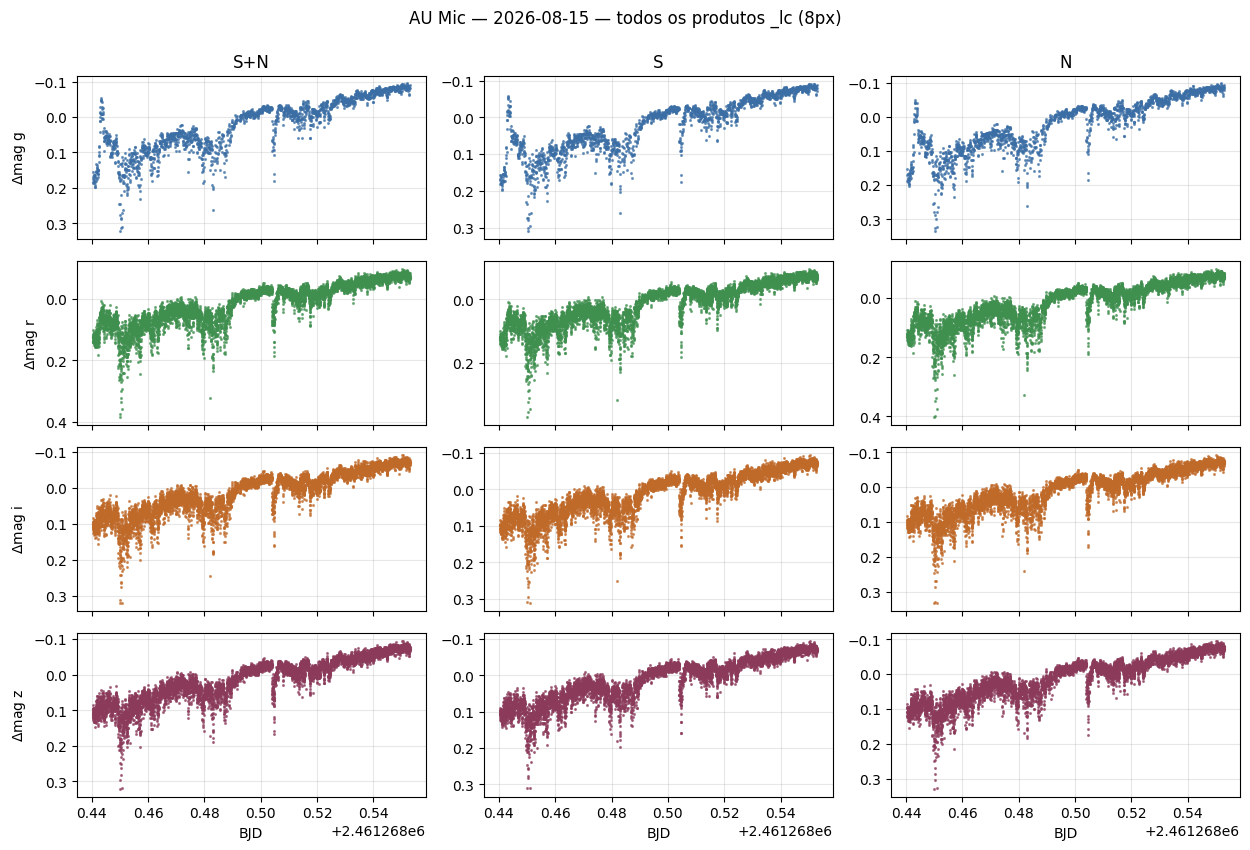

noite 20260815 - abertura 8px

 banda  beam   pontos  arquivo
     g   S+N     1938  20260815_s4c1_AUMic_POLAR_L2_S+N_lc.fits
     g     S     1938  20260815_s4c1_AUMic_POLAR_L2_S_lc.fits
     g     N     1938  20260815_s4c1_AUMic_POLAR_L2_N_lc.fits
     r   S+N     6524  20260815_s4c2_AUMic_POLAR_L2_S+N_lc.fits
     r     S     6524  20260815_s4c2_AUMic_POLAR_L2_S_lc.fits
     r     N     6524  20260815_s4c2_AUMic_POLAR_L2_N_lc.fits
     i   S+N     6524  20260815_s4c3_AUMic_POLAR_L2_S+N_lc.fits
     i     S     6524  20260815_s4c3_AUMic_POLAR_L2_S_lc.fits
     i     N     6524  20260815_s4c3_AUMic_POLAR_L2_N_lc.fits
     z   S+N     6524  20260815_s4c4_AUMic_POLAR_L2_S+N_lc.fits
     z     S     6524  20260815_s4c4_AUMic_POLAR_L2_S_lc.fits
     z     N     6524  20260815_s4c4_AUMic_POLAR_L2_N_lc.fits


In [2]:
# ═══ TODOS os produtos _lc da noite — Δmag do alvo (SRCINDEX 0) vs BJD ═══════
import glob, os, re
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

BASE    = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
DATADIR = os.path.join(BASE, "data")

NOITE = "20260815"
APER  = 8          # abertura pronta no fits (5,8,10,12,15,20,25)

BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}      # s4c1..s4c4
CORES  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}
BEAMS  = ["S+N", "S", "N"]                       # ordem das colunas


def le_alvo(arq, aper=APER):
    with fits.open(arq) as h:
        d = [e for e in h[1:] if e.header.get("APRADIUS") == aper][0].data
    m = (d["SRCINDEX"].astype(int) == 0)
    t    = np.asarray(d["TIME"][m], float)
    mag  = np.asarray(d["MAG"][m],  float)
    emag = np.asarray(d["EMAG"][m], float)
    flag = np.asarray(d["FLAG"][m])
    mag[flag != 0] = np.nan
    o = np.argsort(t); t, mag, emag = t[o], mag[o], emag[o]
    return t, mag - np.nanmedian(mag), emag


# descobre todos os _lc.fits e classifica por banda + feixe
pat  = re.compile(r"_s4c(\d)_.*_(S\+N|S|N)_lc\.fits$")
prod = {}                                        # (banda, beam) -> caminho
for arq in sorted(glob.glob(os.path.join(DATADIR, NOITE, "*_lc.fits"))):
    mt = pat.search(os.path.basename(arq))
    if mt:
        prod[(BANDAS[int(mt.group(1))], mt.group(2))] = arq

beams_exist = [bm for bm in BEAMS if any(k[1] == bm for k in prod)]
bandas_ord  = ["g", "r", "i", "z"]

fig, axs = plt.subplots(len(bandas_ord), len(beams_exist),
                        figsize=(4.2 * len(beams_exist), 8.5),
                        sharex="col", squeeze=False)
for i, b in enumerate(bandas_ord):
    for j, bm in enumerate(beams_exist):
        ax = axs[i, j]
        arq = prod.get((b, bm))
        if arq is None:
            ax.set_axis_off(); continue
        t, dmag, e = le_alvo(arq)
        ax.errorbar(t, dmag, yerr=e, fmt=".", ms=2.5, lw=0,
                    elinewidth=0.4, alpha=0.6, color=CORES[b])
        ax.invert_yaxis(); ax.grid(alpha=0.3)
        if i == 0: ax.set_title(bm)
        if j == 0: ax.set_ylabel(fr"$\Delta$mag {b}")
        if i == len(bandas_ord) - 1: ax.set_xlabel("BJD")
fig.suptitle(f"AU Mic — {NOITE[:4]}-{NOITE[4:6]}-{NOITE[6:]} — todos os produtos _lc ({APER}px)",
             y=0.995)
plt.tight_layout()
plt.show()

# resumo do que foi lido
print(f"noite {NOITE} - abertura {APER}px\n")
print(f"{'banda':>6} {'beam':>5} {'pontos':>8}  arquivo")
for b in bandas_ord:
    for bm in beams_exist:
        arq = prod.get((b, bm))
        if arq:
            t, *_ = le_alvo(arq)
            print(f"{b:>6} {bm:>5} {t.size:>8}  {os.path.basename(arq)}")

## — Fotometria diferencial bruta

Define-se a configuração da análise: **noite**, **feixe** (`S+N`), **abertura fotométrica** e **número de estrelas de comparação** (`NCOMPS`).

A função `le_bruto` constrói a matriz de magnitudes *(fonte × instante)*, zerando os valores associados a `FLAG`. Em seguida, seleciona-se como **alvo** a fonte mais brilhante e as `NCOMPS` fontes seguintes como **estrelas de comparação**.

A fotometria diferencial é então calculada a partir da razão entre o fluxo do alvo e a soma dos fluxos das comparações,

$$
R(t) = \frac{f_{\rm alvo}(t)}
{\displaystyle\sum_{i=1}^{N_{\rm comps}} f_{{\rm comp},i}(t)},
$$

com a respectiva incerteza obtida por **propagação de erros**.

Essa razão reduz os efeitos comuns de **extinção atmosférica e variações de transparência**, sem necessidade de reamostragem temporal ou descarte de pontos. Nesse contexto, uma **flare é tratada como um aumento físico e positivo do fluxo**, portanto, como um *outlier* positivo, e **não deve ser removida por sigma-clipping**.

> **Cadência temporal:** cada banda é mantida em sua cadência nativa — aproximadamente **4,1 s em $g$** e **1,3 s em $r$, $i$ e $z$**. As grades de tempo são, portanto, diferentes entre os canais, e essa diferença é preservada ao longo de toda a análise.


In [3]:
# ═══ 1 · configuração e leitura CRUA dos produtos do pipeline ═══════════════
# Nada aqui é rebinado, suavizado ou normalizado: o que sai é a fotometria de
# abertura como o pipeline gravou, na cadência nativa de cada canal (em
# 2026-08-15: 4.1 s no g e 1.3 s em r/i/z, grades diferentes entre si).
import glob
import os

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE    = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
DATADIR = os.path.join(BASE, "data")
OUTDIR  = os.path.join(BASE, "resultados_flares")

NOITE  = "20260815"
BEAM   = "S+N"     # soma dos dois feixes: cancela a modulação da lâmina
APER   = 8         # raio da abertura, em pixels
NCOMPS = 3         # nº de comparações: as mais brilhantes depois do alvo

BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}
CORES  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}
LAMBDA = {"g": 457, "r": 614, "i": 753, "z": 894}      # nm, efetivo


def le_bruto(ch, noite=NOITE, aper=APER, ncomps=NCOMPS):
    """Fotometria crua de um canal: alvo, comparações e razão, ponto a ponto.

    O alvo é a fonte mais brilhante do campo e as comparações são as `ncomps`
    seguintes. A razão alvo/Σcomparações é a única conta feita — uma divisão,
    que tira extinção e transparência sem tocar na amostragem. Nenhum ponto é
    descartado por ser outlier: a flare é, por definição, um outlier positivo.
    Só viram NaN os pontos que o próprio pipeline marcou com FLAG.
    """
    padrao = os.path.join(DATADIR, noite, f"*_s4c{ch}_*_{BEAM}_lc.fits")
    arq = sorted(glob.glob(padrao))[0]

    with fits.open(arq) as h:
        ext = [e for e in h[1:] if e.header.get("APRADIUS") == aper][0]
        d = ext.data
        src  = np.asarray(d["SRCINDEX"], float).astype(int)
        t    = np.asarray(d["TIME"], float)          # BJD_UTC
        mag  = np.asarray(d["MAG"], float)
        emag = np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"])

    # (fonte, instante) -> matriz
    idx, t_jd = np.unique(src), np.unique(t)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t_jd, t)
    M = np.full((idx.size, t_jd.size), np.nan)
    E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    ruim = np.zeros(M.shape, bool)
    ruim[lin, col] = np.asarray(flag) != 0
    M[ruim] = np.nan

    ordem = np.argsort(np.nanmedian(M, axis=1))      # do mais brilhante
    ia, ic = ordem[0], ordem[1:1 + ncomps]

    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        e_comp = np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
        razao  = f_alvo / f_comp
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], e_comp / np.where(f_comp > 0, f_comp, np.nan))

    return dict(banda=BANDAS[ch], canal=ch, arquivo=os.path.basename(arq),
                alvo=int(idx[ia]), comps=[int(idx[c]) for c in ic],
                t=t_jd, f_alvo=f_alvo, f_comp=f_comp, razao=razao, sig=e_raz,
                cad=float(np.median(np.diff(t_jd)) * 86400))


bruto = {BANDAS[ch]: le_bruto(ch) for ch in BANDAS}

print(f"noite {NOITE[:4]}-{NOITE[4:6]}-{NOITE[6:]} - feixe {BEAM} - abertura {APER} px")
print()
print(f"{'banda':>6} {'pontos':>8} {'cadencia':>10} {'inicio UTC':>12} {'fim UTC':>10}")
for b, d in bruto.items():
    ini = Time(d["t"][0],  format="jd", scale="utc").iso[11:19]
    fim = Time(d["t"][-1], format="jd", scale="utc").iso[11:19]
    print(f"{b:>6} {d['t'].size:>8} {d['cad']:>9.2f}s {ini:>12} {fim:>10}")

noite 2026-08-15 - feixe S+N - abertura 8 px

 banda   pontos   cadencia   inicio UTC    fim UTC
     g     1938      4.12s     22:34:10   01:16:09
     r     6524      1.32s     22:34:09   01:16:13
     i     6524      1.32s     22:34:09   01:16:13
     z     6524      1.32s     22:34:09   01:16:13


##  Recorte da janela da flare e curva $\Delta F/F_0$ nas quatro bandas

Converte o instante de início da flare de **BJD_TDB**, definido na tabela principal, para **BJD_UTC**, correspondente à coluna temporal do FITS. Em seguida, recorta a janela temporal da flare, $[-PAD,\ DUR+PAD]$ minutos, mantendo uma margem de **fluxo quiescente** antes e depois do evento como referência.

Para cada banda, determina o **nível de repouso** (`base`) como a mediana dos pontos anteriores à flare e calcula, apenas para fins de visualização,

$$
\frac{\Delta F}{F_0} = \frac{C(t)}{\mathrm{base}} - 1.
$$

São impressos o instante de pico, a amplitude no pico em **ppm** e a relação sinal/ruído (**S/R**) correspondente.

A célula disponibiliza os vetores `t_g, C_g, ..., t_z, C_z`, em que o tempo está em minutos e $C$ corresponde à razão fotométrica bruta, utilizados nas etapas seguintes.

O gráfico apresenta as quatro bandas em painéis empilhados, preservando a **grade temporal nativa de cada canal**.

flare F01 - inicio 2026-08-15 22:38:10 TDB = 22:37:00 UTC
duracao 17 min + 2 min de margem de cada lado
janela: 22:35:00 a 22:56:00 UTC

 banda   pontos    t pico        amp   S/R pico
                    [min]      [ppm]
     g      262      1.15     208615       49.6
     r      872      1.98     114439       18.3
     i      872      1.98      71248        8.9
     z      872      1.95      73282        7.1


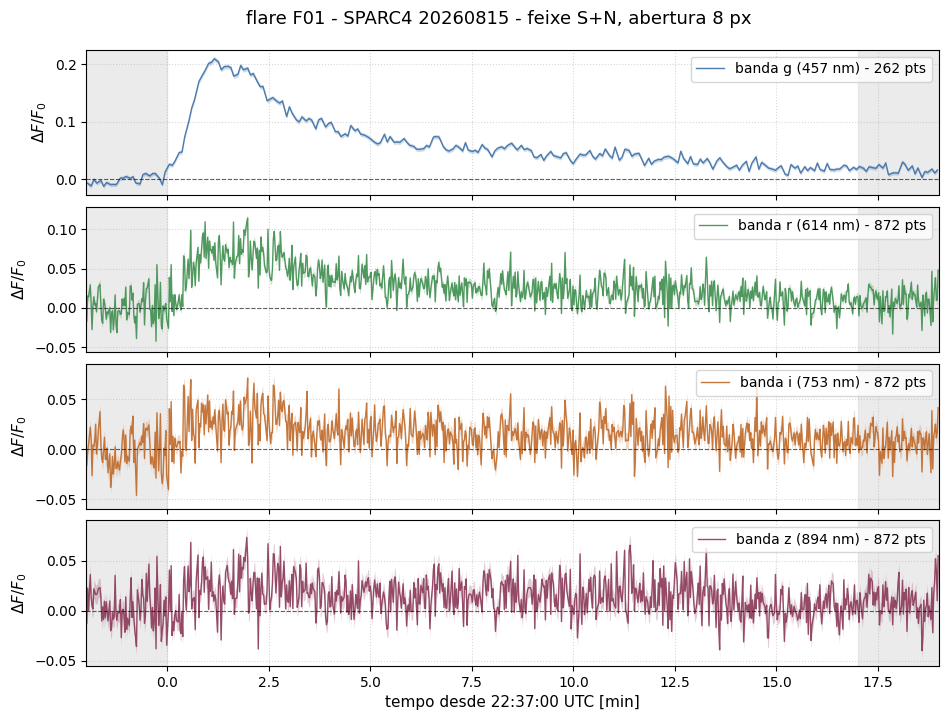

In [4]:
# ═══ 2 · corta a janela da flare e plota ΔF/F₀ nas quatro bandas ════════════
# A janela vem do horário medido da flare (tabela do notebook principal):
# início 22:38:10, 17 min de duração. PAD_MIN acrescenta uma margem de
# quiescente de cada lado — é ela que dá a referência de fluxo fora da flare.
# Cada banda é cortada na SUA grade, sem interpolar para uma grade comum: os
# vetores saem com tamanhos diferentes, e é assim que tem de ser.
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from scipy.stats import sigmaclip

FLARE   = "F01"
INICIO  = "2026-08-15 22:38:10"   # como sai na tabela do notebook principal
ESCALA  = "tdb"                   # ...e essa tabela imprime BJD_TDB, não UTC:
                                  # são 69 s de diferença, mais de um bin. A
                                  # coluna TIME do FITS é BJD_UTC, então o
                                  # horário tem de ser convertido antes do corte.
DUR_MIN = 17                      # duração medida, em minutos
PAD_MIN = 2.0                     # margem de quiescente de cada lado

t0 = Time(INICIO, format="iso", scale=ESCALA).utc.jd   # t = 0 dos vetores
INICIO_UTC = Time(t0, format="jd", scale="utc").iso[11:19]
ja = t0 - PAD_MIN / 1440.0
jb = t0 + (DUR_MIN + PAD_MIN) / 1440.0

flare = {}
for b, d in bruto.items():
    m = (d["t"] >= ja) & (d["t"] <= jb) & np.isfinite(d["razao"])
    t_min = (d["t"][m] - t0) * 1440.0                  # min desde o início
    pre   = d["razao"][m][t_min < 0]
    # nível de repouso: mediana do pré-flare; se a margem não pegou nenhum
    # ponto, cai para sigma-clip assimétrico (corta só o pico positivo).
    base  = float(np.median(pre)) if pre.size else float(
        np.median(sigmaclip(d["razao"][m], low=3.0, high=2.0)[0]))
    flare[b] = dict(
        t_jd   = d["t"][m],          # BJD_UTC, cru
        t_min  = t_min,              # minutos desde o inicio da flare
        razao  = d["razao"][m],      # alvo / soma das comparacoes, cru
        sig    = d["sig"][m],        # erro propagado da fotometria
        f_alvo = d["f_alvo"][m],     # fluxo do alvo, cru
        f_comp = d["f_comp"][m],     # soma das comparacoes, cru
        base   = base,               # nivel pre-flare (referencia, nao aplicado)
        dff    = d["razao"][m] / base - 1.0,   # ΔF/F0, só para o gráfico
        edff   = d["sig"][m] / base,
    )

print(f"flare {FLARE} - inicio {INICIO} {ESCALA.upper()} = {INICIO_UTC} UTC")
print(f"duracao {DUR_MIN:.0f} min + {PAD_MIN:.0f} min de margem de cada lado")
print(f"janela: {Time(ja, format='jd', scale='utc').iso[11:19]} a "
      f"{Time(jb, format='jd', scale='utc').iso[11:19]} UTC")
print()
print(f"{'banda':>6} {'pontos':>8} {'t pico':>9} {'amp':>10} {'S/R pico':>10}")
print(f"{'':>6} {'':>8} {'[min]':>9} {'[ppm]':>10}")
for b, v in flare.items():
    k   = int(np.argmax(v["razao"]))
    amp = (v["razao"][k] / v["base"] - 1.0) * 1e6      # ppm = partes por milhão
    print(f"{b:>6} {v['t_min'].size:>8} {v['t_min'][k]:>9.2f} {amp:>10.0f} "
          f"{(v['razao'][k] - v['base']) / v['sig'][k]:>10.1f}")

# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

# ── gráfico: 4 painéis empilhados, eixo x comum, cada banda na sua grade ────
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"hspace": 0.08})

for ax, b in zip(axes, ["g", "r", "i", "z"]):
    v, cor = flare[b], CORES.get(b, "#333333")
    ax.plot(v["t_min"], v["dff"], color=cor, lw=1.0, alpha=0.9,
            label=f"banda {b} ({LAMBDA[b]} nm) - {v['t_min'].size} pts")
    ax.fill_between(v["t_min"], v["dff"] - v["edff"], v["dff"] + v["edff"],
                    color=cor, alpha=0.25, linewidth=0)
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.axvspan(-PAD_MIN, 0, color="0.85", alpha=0.5, zorder=0)          # pré-flare
    ax.axvspan(DUR_MIN, DUR_MIN + PAD_MIN, color="0.85", alpha=0.5, zorder=0)
    ax.set_ylabel(r"$\Delta F / F_0$", fontsize=11)
    ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.8)
    ax.grid(True, ls=":", alpha=0.5)

axes[-1].set_xlabel(f"tempo desde {INICIO_UTC} UTC [min]", fontsize=11)
axes[-1].set_xlim(-PAD_MIN, DUR_MIN + PAD_MIN)
fig.suptitle(f"flare {FLARE} - SPARC4 {NOITE} - feixe {BEAM}, abertura {APER} px",
             fontsize=13, y=0.93)
plt.show()

## Célula 6 — Modelo de corpo negro: resposta espectral e função de Planck

Lê o arquivo `sparc4_spectral_response.csv`, contendo as curvas de **resposta espectral** $R_\lambda$ das quatro bandas do SPARC4.

São adotados

$$
T_{\rm eff}=3700\ {\rm K},
\qquad
T_{\rm flare}=10^4\ {\rm K},
\qquad
R_\star=0{,}75\,R_\odot,
$$

e a área projetada do disco estelar,

$$
A_\star=\pi R_\star^2.
$$

Para cada canal, identifica os limites espectrais onde $R_\lambda>0$, constrói uma grade própria de **264 pontos**, reamostra a resposta instrumental nessa grade e avalia a função de Planck para a estrela quiescente ($B_s$) e para a flare ($B_f$).

Esta célula apenas prepara as **respostas espectrais, grades e integrais necessárias** para a aplicação das Eqs. (6) e (7).

In [5]:
import numpy as np, pandas as pd
from scipy.integrate import trapezoid
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson


tf   = pd.read_csv("data/sparc4_spectral_response.csv")
nm   = np.array(tf["Wavelength (nm)"])
ry_g = np.array(tf["Channel g (%)"])/100
ry_r = np.array(tf["Channel r (%)"])/100
ry_i = np.array(tf["Channel i (%)"])/100
ry_z = np.array(tf["Channel z (%)"])/100

Teff, Tflare = 3700, 10000
raio     = 0.75*6.968e+8
Aestrela = np.pi*raio**2
sb1      = 5.670374e-8
n        = 264

# limites por canal (onde a resposta é não-nula)
lambda_min_g, lambda_max_g = nm[ry_g>0].min(), nm[ry_g>0].max()   # 350.0 - 683.3 nm
lambda_min_r, lambda_max_r = nm[ry_r>0].min(), nm[ry_r>0].max()   # 448.5 - 1084.8 nm
lambda_min_i, lambda_max_i = nm[ry_i>0].min(), nm[ry_i>0].max()   # 456.1 - 1100.0 nm
lambda_min_z, lambda_max_z = nm[ry_z>0].min(), nm[ry_z>0].max()   # 539.4 - 1100.0 nm

# grade própria de cada canal
wv_g = np.linspace(lambda_min_g, lambda_max_g, n)
wv_r = np.linspace(lambda_min_r, lambda_max_r, n)
wv_i = np.linspace(lambda_min_i, lambda_max_i, n)
wv_z = np.linspace(lambda_min_z, lambda_max_z, n)

# resposta reamostrada na grade do próprio canal
R_g = np.interp(wv_g, nm, ry_g)
R_r = np.interp(wv_r, nm, ry_r)
R_i = np.interp(wv_i, nm, ry_i)
R_z = np.interp(wv_z, nm, ry_z)

# Planck da estrela e da flare, canal a canal
Bs_g, Bf_g = planck(Teff, lam=wv_g*1.e-9), planck(Tflare, lam=wv_g*1.e-9)
Bs_r, Bf_r = planck(Teff, lam=wv_r*1.e-9), planck(Tflare, lam=wv_r*1.e-9)
Bs_i, Bf_i = planck(Teff, lam=wv_i*1.e-9), planck(Tflare, lam=wv_i*1.e-9)
Bs_z, Bf_z = planck(Teff, lam=wv_z*1.e-9), planck(Tflare, lam=wv_z*1.e-9)



##  Reexposição dos vetores $(t,C)$ por banda

Reafirma os vetores `t_g, C_g, ..., t_z, C_z` obtidos no recorte da flare.

Esta célula tem função de **organização e segurança de execução**, garantindo que os vetores temporais e fotométricos de cada banda estejam disponíveis mesmo quando as células do notebook forem executadas fora da ordem original.

Os dados de cada canal permanecem em sua **própria grade temporal**, sem interpolação ou reamostragem entre bandas.

In [6]:
# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

##  — Amplitude relativa $\Delta F/F$ da banda $g$

Seleciona o trecho **quiescente** anterior ao pico da flare e determina o nível de referência como a mediana desse trecho.

A amplitude relativa é calculada por

$$
a_g(t)=\frac{C_g(t)-\mathrm{base}_g}{\mathrm{base}_g}.
$$

Para representar exclusivamente o **excesso de emissão associado à flare**, os valores negativos são truncados em zero,

$$
a_g(t)=\max\left(0,\frac{C_g(t)-\mathrm{base}_g}
{\mathrm{base}_g}\right).
$$

O truncamento é realizado preservando o mesmo alinhamento temporal de `t_g`.

A célula imprime a amplitude máxima em **fração relativa** e em **ppm**, além de apresentar a curva da flare.

> **Observação:** o `offset = 0.02` e o rótulo `Tempo [dias]` foram herdados de um esboço anterior. Como os vetores desta análise estão em **minutos**, esses elementos devem ser revisados antes da utilização da figura final.

## Amplitude relativa $\Delta F/F$ da banda $g$

Aplica o mesmo procedimento de determinação da **amplitude relativa da flare** para todas as bandas $g$, $r$, $i$ e $z$.

Para cada canal, são realizados:

- definição do nível quiescente;
- cálculo da amplitude relativa;
- truncamento dos valores negativos em zero;
- preservação da grade temporal nativa de cada banda;
- determinação da amplitude máxima;
- representação gráfica da curva da flare.

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
g (fração): 0.201469
g (ppm):    201469 ppm


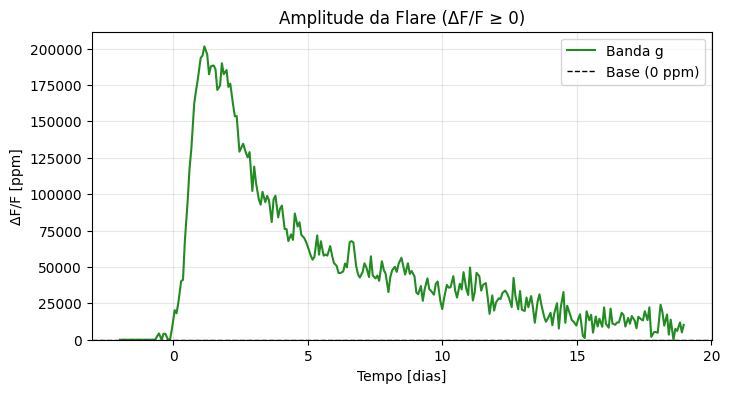

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora = t_g < t_g[np.argmax(C_g)] - 0.02  # ajuste o offset em dias conforme sua curva
a_g = amplitude(t_g, C_g, fora)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_g' perfeitamente alinhado
a_g_pos = np.maximum(a_g, 0)
a_g_ppm_pos = a_g_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos = a_g >= 0
t_g_filtrado = t_g[mask_pos]
a_g_filtrado = a_g[mask_pos]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"g (fração): {np.max(a_g_pos):.6f}")
print(f"g (ppm):    {np.max(a_g_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_g, a_g_ppm_pos, label="Banda g", color="forestgreen")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [dias]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Célula 9 — Área da flare na banda $g$ pela Eq. (6), passo a passo

Aplica a **Eq. (6)** no instante de pico da flare, utilizando

$$
a_{\rm pico}=C_{\max}-1.
$$

Calcula as integrais ponderadas pela resposta espectral da banda $g$,

$$
\int B_s R_\lambda\,d\lambda,
$$

$$
\int B_f R_\lambda\,d\lambda,
$$

e

$$
\int (B_f-B_s)R_\lambda\,d\lambda.
$$

A área da região ativa é obtida por

$$
A_{\rm flare}
=
a_{\rm pico}\,A_\star
\frac{\displaystyle\int B_sR_\lambda\,d\lambda}
{\displaystyle\int(B_f-B_s)R_\lambda\,d\lambda}.
$$

A célula imprime individualmente os principais termos do cálculo: `base`, amplitude, $A_\star$, integrais, numerador e denominador.

Também é calculada a **fração do disco estelar coberta pela flare**.

> **Unidades:** nesta etapa, $\lambda$ é expressa em nm. Como a mesma unidade aparece no numerador e no denominador, os fatores de conversão se cancelam na razão. Na Célula 11, o cálculo é refeito integralmente em **metros**, utilizando o SI.

In [8]:
import numpy as np
from scipy.integrate import simpson

# 1. Normalização e determinação do fluxo de base (quiescente)
base_g = np.median(C_g[fora])
C_norm = C_g / base_g

# 2. Fluxo no pico e Amplitude Relativa ΔF/F
c_max_g = np.max(C_norm)
amp_max_g = c_max_g - 1.0  # max(C - 1)

# 3. Integrais do espectro convoluído com a resposta do filtro
int_estrela = simpson(Bs_g * R_g, wv_g)  # Integral de F_star * S_lambda
int_flare = simpson(Bf_g * R_g, wv_g)  # Integral de B_lambda(T_flare) * S_lambda
int_diff = simpson(
    (Bf_g - Bs_g) * R_g, wv_g
)  # Integral de (B_lambda - F_star) * S_lambda

# 4. Cálculo do Numerador e Denominador da Equação (6)
num = amp_max_g * Aestrela * int_estrela
den = int_diff

# 5. Área final da flare
area = num / den

# =======================================================
# VERIFICAÇÃO PASSO A PASSO DOS VALORES
# =======================================================
print("=== PASSO A PASSO DO CÁLCULO DA ÁREA (BANDA g) ===")
print(f"1. Fluxo quiescente de base (mediana):   {base_g:.6e}")
print(f"2. Fluxo relativo no pico (c_max_g):     {c_max_g:.6f}")
print(f"3. Amplitude relativa max (c_max - 1):   {amp_max_g:.6f}  (ou {amp_max_g * 1e6:.0f} ppm)")
print(f"4. Área projetada da estrela (Aestrela): {Aestrela:.6e} m²")
print(f"5. Integral do fluxo estelar (Bs):       {int_estrela:.6e}")
print(f"6. Integral do fluxo do corpo negro (Bf): {int_flare:.6e}")
print(f"7. Integral da diferença (Bf - Bs):      {int_diff:.6e}")
print("-" * 55)
print(f"TERMO NUMERADOR   (num):                 {num:.6e}")
print(f"TERMO DENOMINADOR (den):                 {den:.6e}")
print("=" * 55)
print(f"ÁREA REAL DA FLARE (A_flare):            {area:.3e} m²")
print(f"FRAÇÃO DO DISCO ESTELAR (A_flare/Astar):  {(area / Aestrela) * 100:.4f}%  (ou {(area / Aestrela) * 1e6:.0f} ppm)")

=== PASSO A PASSO DO CÁLCULO DA ÁREA (BANDA g) ===
1. Fluxo quiescente de base (mediana):   8.289171e+00
2. Fluxo relativo no pico (c_max_g):     1.201469
3. Amplitude relativa max (c_max - 1):   0.201469  (ou 201469 ppm)
4. Área projetada da estrela (Aestrela): 8.580028e+17 m²
5. Integral do fluxo estelar (Bs):       5.243340e+14
6. Integral do fluxo do corpo negro (Bf): 1.171842e+17
7. Integral da diferença (Bf - Bs):      1.166598e+17
-------------------------------------------------------
TERMO NUMERADOR   (num):                 9.063667e+31
TERMO DENOMINADOR (den):                 1.166598e+17
ÁREA REAL DA FLARE (A_flare):            7.769e+14 m²
FRAÇÃO DO DISCO ESTELAR (A_flare/Astar):  0.0906%  (ou 906 ppm)


## Célula 11 — Método completo na banda $g$: $A_{\rm flare}$, $T(t)$, $L(t)$ e $E$

Aplica o método completo de modelagem da flare na banda $g$, seguindo as **Eqs. (6)–(9)** e utilizando $\lambda$ em **metros**, com as grandezas físicas no SI.

O procedimento é:

1. **Eq. (6) — área da flare:** determina $A_{\rm flare}$ a partir da amplitude máxima observada, assumindo uma temperatura máxima da flare de $T_{\rm flare}^{\max}=10^4$ K. A área é mantida constante durante todo o evento.

2. **Eq. (7) — evolução da temperatura:** com $A_{\rm flare}$ fixada, a equação

$$
\int_{\lambda_1}^{\lambda_2}
S_\lambda B_\lambda(T_{\rm flare})\,d\lambda
=
\left(
\frac{(C-1)A_{\rm star}}{A_{\rm flare}}+1
\right)
\int_{\lambda_1}^{\lambda_2}
S_\lambda F_{\rm star}\,d\lambda
$$

é resolvida para cada instante da flare, permitindo determinar a evolução temporal da temperatura $T_{\rm flare}(t)$.

Para acelerar o cálculo, a integral

$$
\int_{\lambda_1}^{\lambda_2}
S_\lambda B_\lambda(T)\,d\lambda
$$

é previamente calculada para uma grade de temperaturas e utilizada como uma *lookup table*. A temperatura correspondente a cada instante é então obtida por interpolação.

3. **Eq. (8) — luminosidade bolométrica:** a partir de $T_{\rm flare}(t)$ e da área fixa, calcula

$$
L_{\rm flare}(t)
=
\sigma_{\rm SB}A_{\rm flare}T_{\rm flare}^4(t).
$$

4. **Eq. (9) — energia total:** integra a luminosidade durante a duração da flare,

$$
E_{\rm flare}
=
\int_{\rm flare}L_{\rm flare}(t)\,dt
=
A_{\rm flare}\sigma_{\rm SB}
\int_{\rm flare}T_{\rm flare}^4(t)\,dt.
$$

O tempo é convertido de minutos para segundos para realizar a integração, resultando em energia em **joules**, posteriormente convertida para **ergs**.

A célula apresenta um resumo das grandezas físicas obtidas e plota a evolução temporal de $T_{\rm flare}(t)$ e $L_{\rm flare}(t)$.

O mesmo procedimento é aplicado **independentemente a cada banda**, utilizando a resposta espectral e a grade temporal nativas de cada canal.

In [9]:
import numpy as np
from scipy.integrate import simpson

# =======================================================
# PASSO 1: TERMOS BASE E INTEGRAL QUIESCENTE DA ESTRELA
# =======================================================
# Integral de S_lambda * F_star (fluxo da estrela quiescente)
int_estrela = simpson(Bs_g * R_g, wv_g)

# Amplitude máxima no pico (C - 1)
amp_pico = np.max(a_g)  # ou (c_max_g - 1)

# =======================================================
# PASSO 2: CÁLCULO DO LADO DIREITO (RHS) DA EQ. (7) NO PICO
# =======================================================
# Termo 1: Razão de áreas multiplicada pela amplitude
termo_area = (amp_pico * Aestrela) / area  # (C - 1) * A_star / A_flare

# Termo 2: Fator multiplicativo entre parênteses
fator_mult = termo_area + 1.0  # ( (C - 1)*A_star / A_flare + 1 )

# Termo 3: Lado Direito Completo (RHS) da Equação (7)
rhs_pico = fator_mult * int_estrela

# =======================================================
# PASSO 3: VERIFICAÇÃO COM O LADO ESQUERDO (LHS - TEÓRICO)
# =======================================================
# Integral teórica de S_lambda * B_lambda(T_flare_max) a 10.000 K
lhs_teorico = simpson(Bf_g * R_g, wv_g)

# Diferença relativa para validação
diferenca = abs(rhs_pico - lhs_teorico) / lhs_teorico * 100

# =======================================================
# IMPRESSÃO E VERIFICAÇÃO DETALHADA
# =======================================================
print("=== VERIFICAÇÃO PASSO A PASSO DA EQUAÇÃO (7) NO PICO ===")
print(f"1. Amplitude no pico (C - 1):               {amp_pico:.6f}")
print(f"2. Área da Estrela (A_star):                {Aestrela:.6e} m²")
print(f"3. Área da Flare (A_flare):                 {area:.6e} m²")
print(f"4. Termo [(C - 1) * A_star / A_flare]:       {termo_area:.6f}")
print(f"5. Fator Completo [(... ) + 1]:             {fator_mult:.6f}")
print(f"6. Integral Quiescente ∫ S_λ F_star dλ:     {int_estrela:.6e}")
print("-" * 55)
print(f"LADO DIREITO (RHS da Eq. 7 Calculado):       {rhs_pico:.6e}")
print(f"LADO ESQUERDO (LHS Teórico a 10.000 K):      {lhs_teorico:.6e}")
print("-" * 55)
print(f"Diferença relativa entre LHS e RHS:         {diferenca:.8f}%")

=== VERIFICAÇÃO PASSO A PASSO DA EQUAÇÃO (7) NO PICO ===
1. Amplitude no pico (C - 1):               0.201469
2. Área da Estrela (A_star):                8.580028e+17 m²
3. Área da Flare (A_flare):                 7.769313e+14 m²
4. Termo [(C - 1) * A_star / A_flare]:       222.491415
5. Fator Completo [(... ) + 1]:             223.491415
6. Integral Quiescente ∫ S_λ F_star dλ:     5.243340e+14
-------------------------------------------------------
LADO DIREITO (RHS da Eq. 7 Calculado):       1.171842e+17
LADO ESQUERDO (LHS Teórico a 10.000 K):      1.171842e+17
-------------------------------------------------------
Diferença relativa entre LHS e RHS:         0.00000000%


<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\2897023807.py:112: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_g, T_flare_t, color="mediumseagreen", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\2897023807.py:130: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL g (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.201469  (201469 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        7.769313e+14 m²
Fração do Disco Estelar:             0.0906%  (906 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      4.405473e+23 W
                                     4.405473e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.367884e+26 J
 -> Em Ergs:                        1.367884e+33 erg


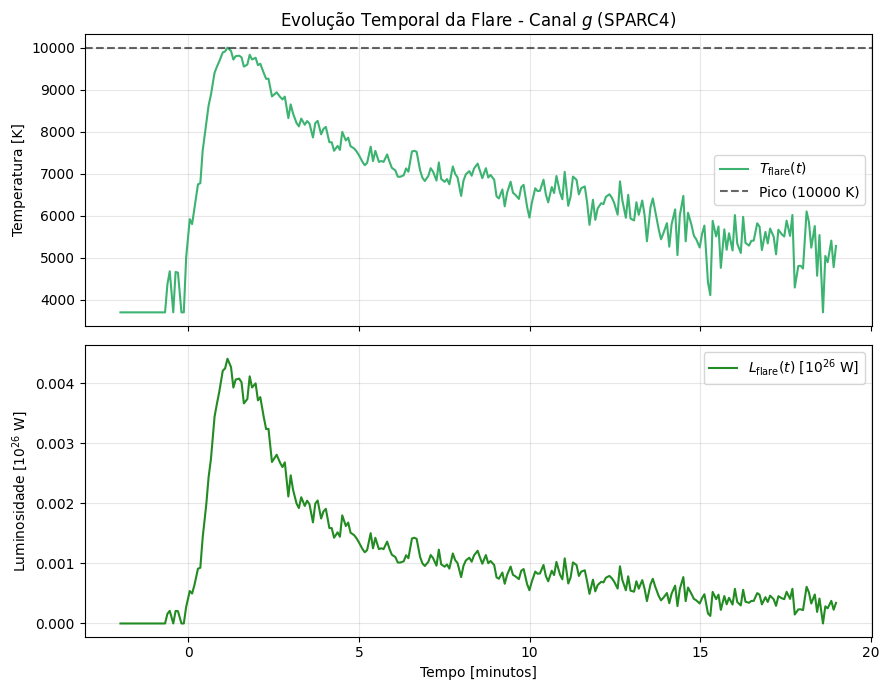

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SEU SETUP INICIAL (SPARC4 - CANAL g)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_g = np.array(tf["Channel g (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal g (350.0 a 683.3 nm) e resposta interpolada
lambda_min_g, lambda_max_g = nm[ry_g > 0].min(), nm[ry_g > 0].max()
wv_g = np.linspace(lambda_min_g, lambda_max_g, n)
R_g = np.interp(wv_g, nm, ry_g)

# ATENÇÃO: Comprimento de onda em METROS para as integrais do Simpson
wv_g_m = wv_g * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_g = planck(Teff, lam=wv_g_m)
Bf_g = planck(Tflare, lam=wv_g_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Supondo a_g = DeltaF/F e t_g em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_g_pos = np.maximum(a_g, 0)
amp_pico = np.max(a_g_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_g * R_g, wv_g_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_g * R_g, wv_g_m)  # Integral do corpo negro da flare
int_diff = simpson(
    (Bf_g - Bs_g) * R_g, wv_g_m
)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_g_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_g_m) * R_g, wv_g_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(
    a_g > 0, sb1 * A_flare * (T_flare_t**4), 0.0
)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_g * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL g (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print(f"ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_g, T_flare_t, color="mediumseagreen", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $g$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_g,
    L_flare_t / 1e26,
    color="forestgreen",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
r (fração): 0.096316
r (ppm):    96316 ppm


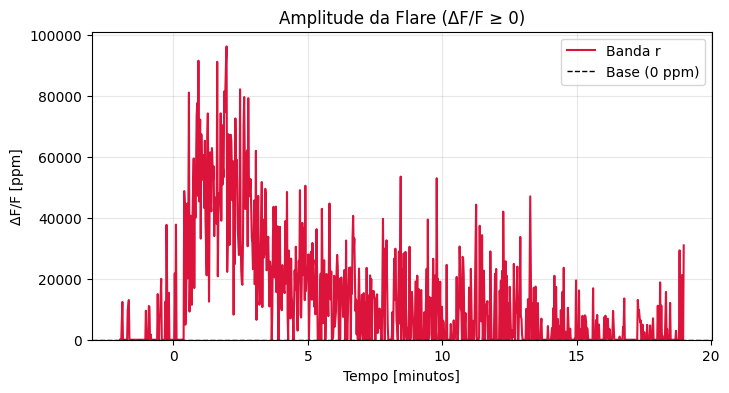

In [11]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora = t_r < t_r[np.argmax(C_r)] - 0.02  # ajuste o offset de tempo se necessário
a_r = amplitude(t_r, C_r, fora)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_r' perfeitamente alinhado
a_r_pos = np.maximum(a_r, 0)
a_r_ppm_pos = a_r_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos = a_r >= 0
t_r_filtrado = t_r[mask_pos]
a_r_filtrado = a_r[mask_pos]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"r (fração): {np.max(a_r_pos):.6f}")
print(f"r (ppm):    {np.max(a_r_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_r, a_r_ppm_pos, label="Banda r", color="crimson")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\1320871341.py:111: SyntaxWarning: invalid escape sequence '\m'
  t_r, T_flare_t, color="crimson", label="$T_{\mathrm{flare}}(t)$"
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\1320871341.py:130: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL r (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.096316  (96316 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        1.358606e+15 m²
Fração do Disco Estelar:             0.1583%  (1583 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      7.703786e+23 W
                                     7.703786e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.093951e+26 J
 -> Em Ergs:                        1.093951e+33 erg


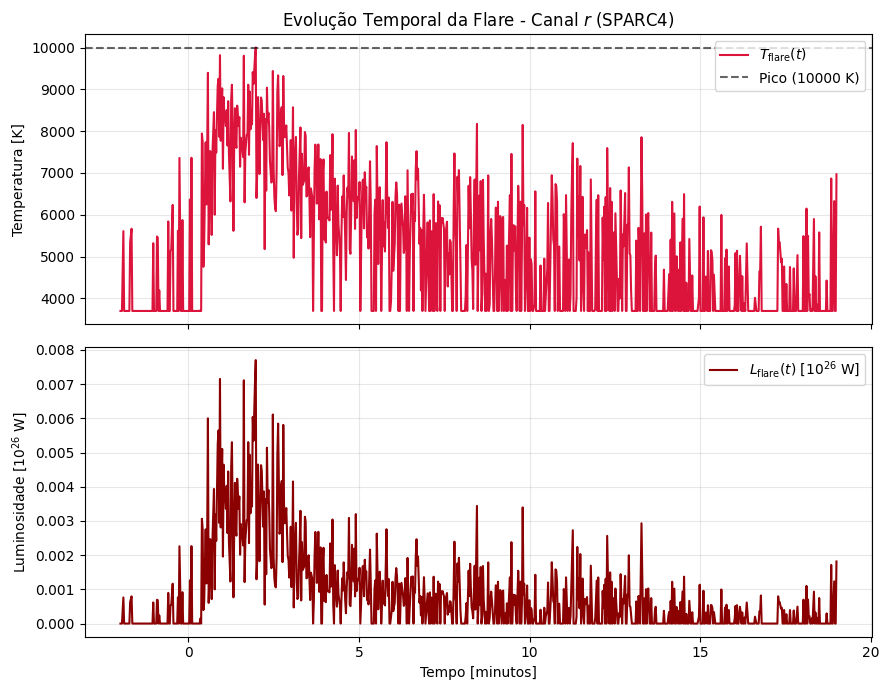

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL r)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_r = np.array(tf["Channel r (%)"]) / 100.0  # Corrigido para Channel r (%)

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal r e resposta interpolada
lambda_min_r, lambda_max_r = nm[ry_r > 0].min(), nm[ry_r > 0].max()
wv_r = np.linspace(lambda_min_r, lambda_max_r, n)
R_r = np.interp(wv_r, nm, ry_r)

# Comprimento de onda em METROS para as integrais do Simpson
wv_r_m = wv_r * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_r = planck(Teff, lam=wv_r_m)
Bf_r = planck(Tflare, lam=wv_r_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_r = DeltaF/F e t_r em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_r_pos = np.maximum(a_r, 0)
amp_pico = np.max(a_r_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_r * R_r, wv_r_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_r * R_r, wv_r_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_r - Bs_r) * R_r, wv_r_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_r_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_r_m) * R_r, wv_r_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(
    a_r > 0, sb1 * A_flare * (T_flare_t**4), 0.0
)  # Corrigido para a_r

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_r * 60.0  # Corrigido para t_r

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL r (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print(f"ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(
    t_r, T_flare_t, color="crimson", label="$T_{\mathrm{flare}}(t)$"
)  # Corrigido para t_r
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $r$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_r,
    L_flare_t / 1e26,
    color="darkred",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)  # Corrigido para t_r
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
i (fração): 0.060511
i (ppm):    60511 ppm


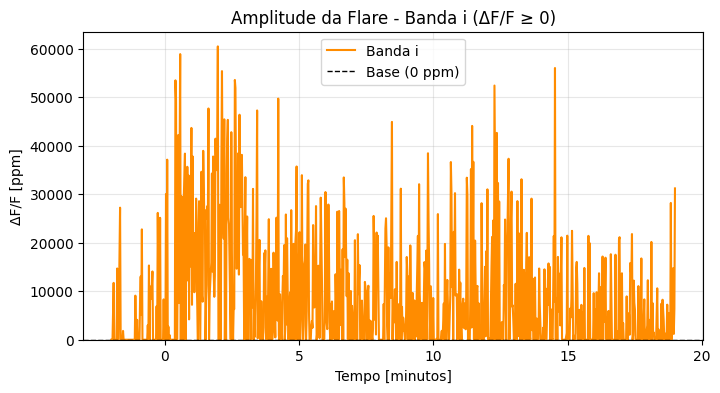

In [13]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora_i = t_i < t_i[np.argmax(C_i)] - 0.02  # ajuste o offset de tempo se necessário
a_i = amplitude(t_i, C_i, fora_i)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_i' perfeitamente alinhado
a_i_pos = np.maximum(a_i, 0)
a_i_ppm_pos = a_i_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos_i = a_i >= 0
t_i_filtrado = t_i[mask_pos_i]
a_i_filtrado = a_i[mask_pos_i]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"i (fração): {np.max(a_i_pos):.6f}")
print(f"i (ppm):    {np.max(a_i_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_i, a_i_ppm_pos, label="Banda i", color="darkorange")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare - Banda i (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\3728777931.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_i, T_flare_t, color="darkorange", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\3728777931.py:126: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL i (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.060511  (60511 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        1.732513e+15 m²
Fração do Disco Estelar:             0.2019%  (2019 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      9.823996e+23 W
                                     9.823996e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.285860e+26 J
 -> Em Ergs:                        1.285860e+33 erg


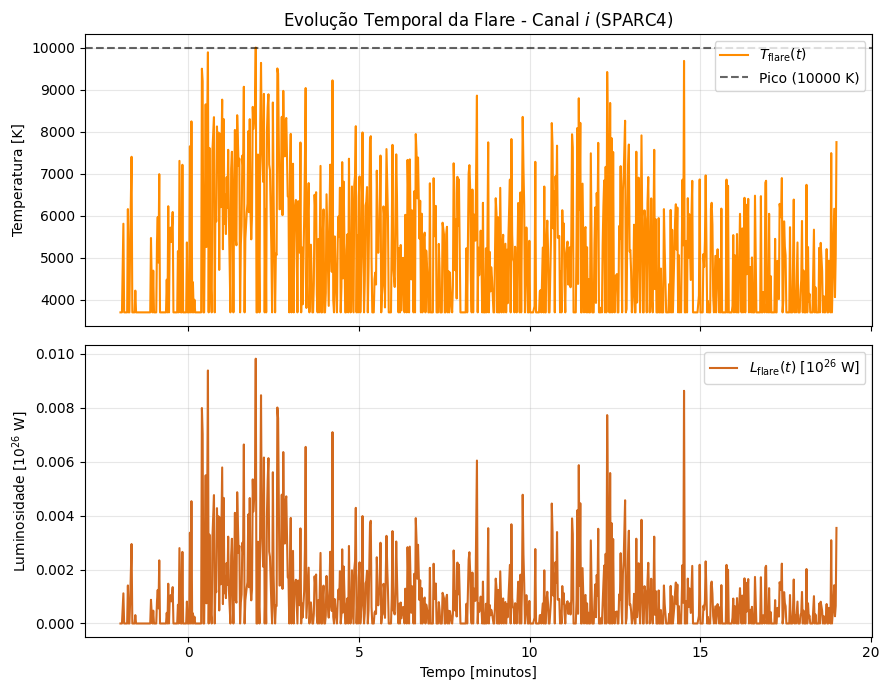

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL i)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_i = np.array(tf["Channel i (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal i e resposta interpolada
lambda_min_i, lambda_max_i = nm[ry_i > 0].min(), nm[ry_i > 0].max()
wv_i = np.linspace(lambda_min_i, lambda_max_i, n)
R_i = np.interp(wv_i, nm, ry_i)

# Comprimento de onda em METROS para as integrais do Simpson
wv_i_m = wv_i * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_i = planck(Teff, lam=wv_i_m)
Bf_i = planck(Tflare, lam=wv_i_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_i = DeltaF/F e t_i em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_i_pos = np.maximum(a_i, 0)
amp_pico = np.max(a_i_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_i * R_i, wv_i_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_i * R_i, wv_i_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_i - Bs_i) * R_i, wv_i_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_i_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 10000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_i_m) * R_i, wv_i_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(a_i > 0, sb1 * A_flare * (T_flare_t**4), 0.0)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_i * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL i (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print("ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_i, T_flare_t, color="darkorange", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $i$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_i,
    L_flare_t / 1e26,
    color="chocolate",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
z (fração): 0.061613
z (ppm):    61613 ppm


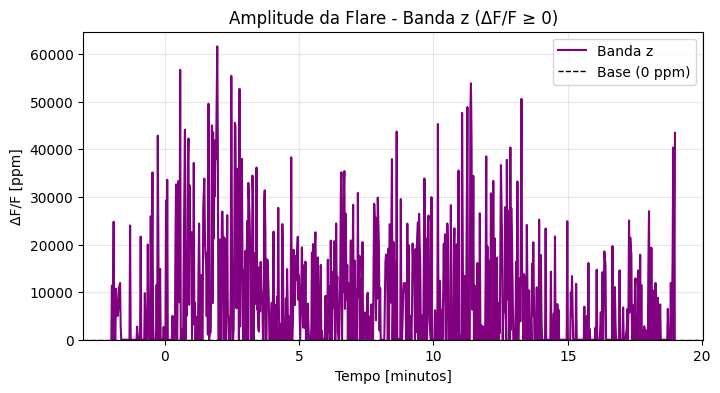

In [15]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora_z = t_z < t_z[np.argmax(C_z)] - 0.02  # ajuste o offset de tempo se necessário
a_z = amplitude(t_z, C_z, fora_z)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_z' perfeitamente alinhado
a_z_pos = np.maximum(a_z, 0)
a_z_ppm_pos = a_z_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos_z = a_z >= 0
t_z_filtrado = t_z[mask_pos_z]
a_z_filtrado = a_z[mask_pos_z]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"z (fração): {np.max(a_z_pos):.6f}")
print(f"z (ppm):    {np.max(a_z_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_z, a_z_ppm_pos, label="Banda z", color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare - Banda z (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\3288129018.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_z, T_flare_t, color="purple", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_4172\3288129018.py:126: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL z (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.061613  (61613 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        2.850750e+15 m²
Fração do Disco Estelar:             0.3323%  (3323 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      1.616480e+24 W
                                     1.616480e+31 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.693861e+26 J
 -> Em Ergs:                        1.693861e+33 erg


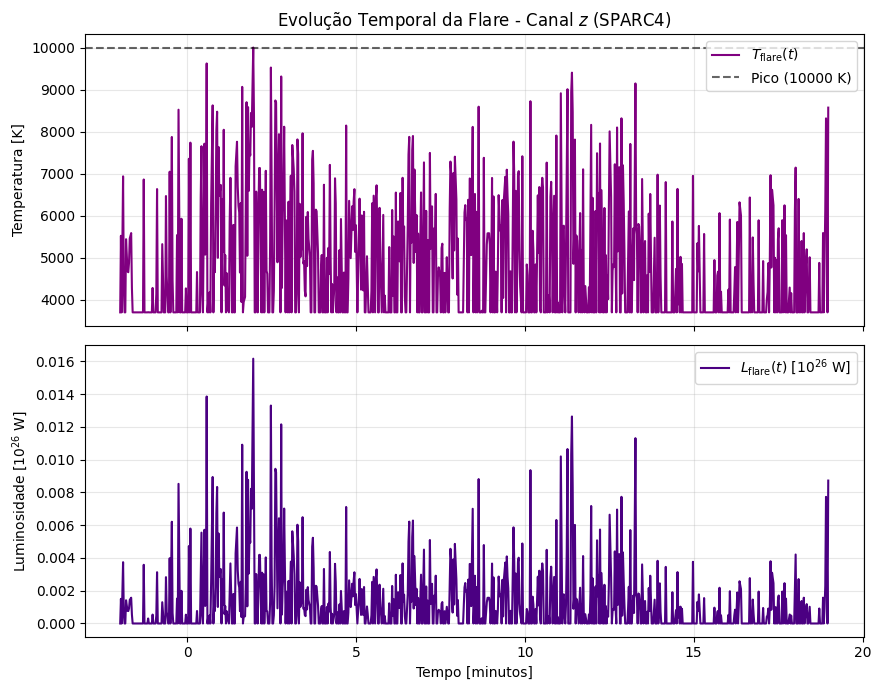

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL z)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_z = np.array(tf["Channel z (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal z e resposta interpolada
lambda_min_z, lambda_max_z = nm[ry_z > 0].min(), nm[ry_z > 0].max()
wv_z = np.linspace(lambda_min_z, lambda_max_z, n)
R_z = np.interp(wv_z, nm, ry_z)

# Comprimento de onda em METROS para as integrais do Simpson
wv_z_m = wv_z * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_z = planck(Teff, lam=wv_z_m)
Bf_z = planck(Tflare, lam=wv_z_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_z = DeltaF/F e t_z em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_z_pos = np.maximum(a_z, 0)
amp_pico = np.max(a_z_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_z * R_z, wv_z_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_z * R_z, wv_z_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_z - Bs_z) * R_z, wv_z_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_z_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_z_m) * R_z, wv_z_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(a_z > 0, sb1 * A_flare * (T_flare_t**4), 0.0)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_z * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL z (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print("ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_z, T_flare_t, color="purple", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $z$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_z,
    L_flare_t / 1e26,
    color="indigo",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

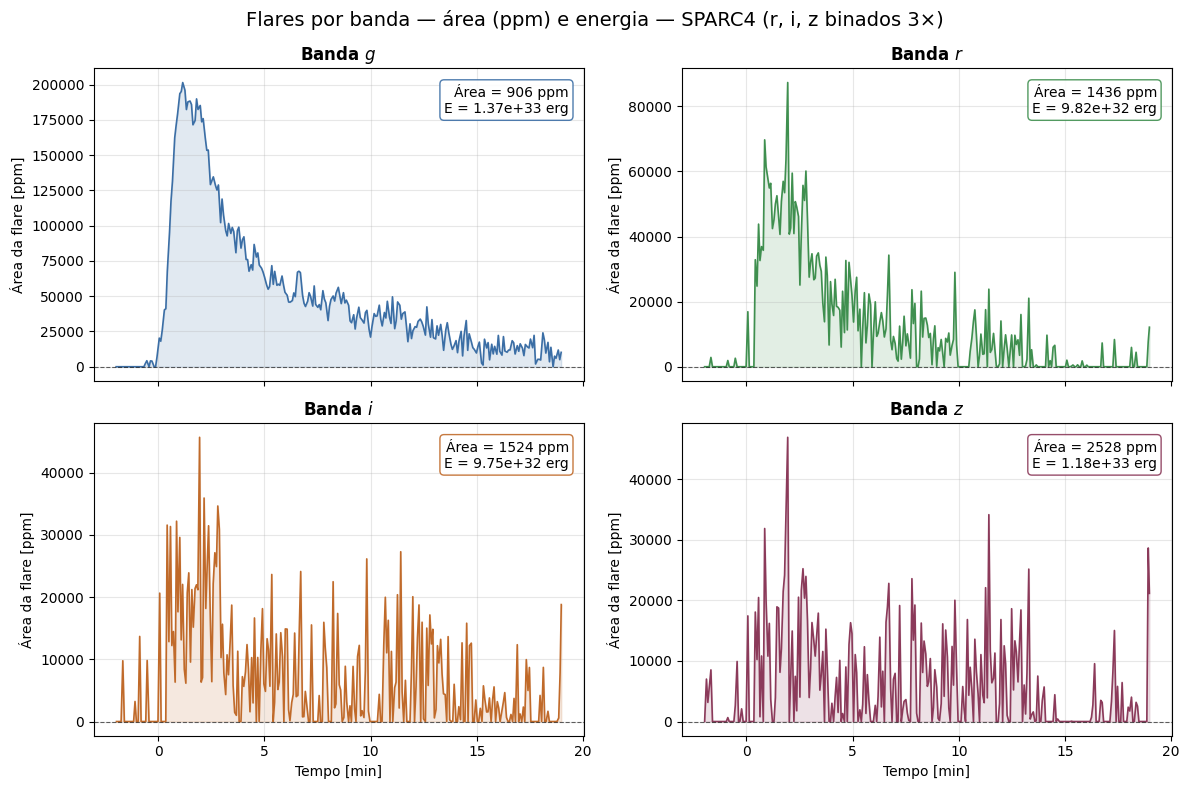

 banda   área [ppm]    energia [erg]
     g          906        1.368e+33
     r         1436        9.824e+32
     i         1524        9.754e+32
     z         2528        1.179e+33


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# --- entradas por banda (amplitudes e tempos já calculados) ---
bandas  = ["g", "r", "i", "z"]
ampl    = {"g": a_g, "r": a_r, "i": a_i, "z": a_z}
tempos  = {"g": t_g, "r": t_r, "i": t_i, "z": t_z}
col_csv = {"g": "Channel g (%)", "r": "Channel r (%)",
           "i": "Channel i (%)", "z": "Channel z (%)"}
cores   = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

# --- bina r, i, z (agrupa 3 pontos ~1.3s -> ~3.96s, cadência da banda g) ---
BIN = 3

def binna(x, y, k):
    m  = (len(x) // k) * k
    xb = np.nanmean(x[:m].reshape(-1, k), axis=1)
    yb = np.nanmean(y[:m].reshape(-1, k), axis=1)
    if m < len(x):                     # sobra de pontos no fim
        xb = np.append(xb, np.nanmean(x[m:]))
        yb = np.append(yb, np.nanmean(y[m:]))
    return xb, yb

for b in ("r", "i", "z"):
    tempos[b], ampl[b] = binna(tempos[b], ampl[b], BIN)   # g fica intacta

# --- cálculo físico por banda (Eqs. 6-9) ---
T_grid = np.linspace(2000, 25000, 1000)
res = {}

for b in bandas:
    a   = np.maximum(ampl[b], 0.0)          # ΔF/F truncado em zero (emissão real)
    tmn = tempos[b]                         # tempo [min]
    ry  = np.asarray(tf[col_csv[b]], float) / 100.0
    lo, hi = nm[ry > 0].min(), nm[ry > 0].max()
    wv  = np.linspace(lo, hi, n)
    R   = np.interp(wv, nm, ry)
    wvm = wv * 1e-9                          # metros
    Bs  = planck(Teff,   lam=wvm)
    Bf  = planck(Tflare, lam=wvm)
    # Eq.(6) área da flare no pico
    int_Bs   = simpson(Bs * R, wvm)
    int_diff = simpson((Bf - Bs) * R, wvm)
    A_flare  = (a.max() * Aestrela * int_Bs) / int_diff
    area_ppm = (A_flare / Aestrela) * 1e6
    # Eq.(7) T(t) por inversão (lookup table)
    rhs = (a * Aestrela / A_flare + 1.0) * int_Bs
    lhs = np.array([simpson(planck(T, lam=wvm) * R, wvm) for T in T_grid])
    T_t = np.interp(rhs, lhs, T_grid)
    # Eq.(8)-(9) luminosidade excedente e energia
    L_t   = np.where(np.maximum(ampl[b], 0.0) > 0,
                     sb1 * A_flare * (T_t**4), 0.0)
    E_erg = simpson(L_t, tmn * 60.0) * 1e7
    res[b] = dict(t=tmn, ppm=a * 1e6, area_ppm=area_ppm, E_erg=E_erg)

# --- painel 2x2: [g, r] em cima | [i, z] embaixo ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ordem = [("g", axes[0, 0]), ("r", axes[0, 1]),
         ("i", axes[1, 0]), ("z", axes[1, 1])]

for b, ax in ordem:
    d = res[b]
    ax.plot(d["t"], d["ppm"], color=cores[b], lw=1.2)
    ax.fill_between(d["t"], 0, d["ppm"], color=cores[b], alpha=0.15)
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(f"Banda ${b}$", fontsize=12, fontweight="bold")
    ax.set_ylabel("Área da flare [ppm]")
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.95,
            f"Área = {d['area_ppm']:.0f} ppm\nE = {d['E_erg']:.2e} erg",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec=cores[b], alpha=0.9))

axes[1, 0].set_xlabel("Tempo [min]")
axes[1, 1].set_xlabel("Tempo [min]")
plt.suptitle("Flares por banda — área (ppm) e energia — SPARC4 "
             "(r, i, z binados 3×)", fontsize=14)
plt.tight_layout()
plt.show()

# resumo numérico
print(f"{'banda':>6} {'área [ppm]':>12} {'energia [erg]':>16}")
for b in bandas:
    print(f"{b:>6} {res[b]['area_ppm']:>12.0f} {res[b]['E_erg']:>16.3e}")

## Temperatura da flare pelas razões de cor entre bandas

Determinação da temperatura da flare **independente** do método de área: em vez de assumir $T_{\rm flare}=10^4$ K, a temperatura sai das **cores** da flare — as razões de fluxo entre pares de banda — comparadas a um corpo negro. Segue a abordagem de Howard et al.

**Passos do código:**

1. **Constantes e resposta espectral** — $h,c,k_B$ e as curvas $R_\lambda$ dos 4 canais do SPARC4 (`sparc4_spectral_response.csv`).
2. **Grade por canal** (`make_grid`) e **lei de Planck** própria (`planck_lambda` / `band_flux_single`), sem depender de bibliotecas externas — bom para os orientadores conferirem a física linha a linha.
3. **Estrela quiescente** — fluxo integrado por banda $B_{\star,X}=\int B_\lambda(T_{\rm eff})\,R_\lambda\,d\lambda$, com $T_{\rm eff}=3700$ K.
4. **Fluxo excedente observado** da flare: $\Delta F_X \propto a_X\,B_{\star,X}$, onde $a_X=(\Delta F/F_0)_X$ é a amplitude medida em cada banda (`amp_g…amp_z`).
5. **Cores observadas** — razões $\mathcal{R}_{XY}^{\rm obs}=\Delta F_X/\Delta F_Y$ (g/r, g/i, g/z, r/i, r/z, i/z).
6. **Cores teóricas** — para uma grade de 500–50 000 K, calcula $I_X(T)=\int B_\lambda(T)\,R_\lambda\,d\lambda$ (vetorizado em toda a grade) e as razões $\mathcal{R}_{XY}^{\rm mod}(T)=I_X(T)/I_Y(T)$.
7. **Temperatura por par** (`get_temperature`) — o $T$ cujo $\mathcal{R}^{\rm mod}(T)$ mais se aproxima do $\mathcal{R}^{\rm obs}$ observado.
8. **Ajuste conjunto** — combina g/r, g/i e g/z num $\chi^2$ de diferenças relativas e toma o mínimo como $T_{\rm flare}$ final.
9. **Verificação e gráfico** — compara observado × modelo na $T$ ajustada e plota $\mathcal{R}_{XY}(T)$ com a temperatura marcada.

**Por que funciona.** A razão entre bandas **cancela a área** $A_{\rm flare}$: $\Delta F_X/\Delta F_Y = I_X(T)/I_Y(T)$ depende só da **temperatura** (a forma do espectro de corpo negro), não do tamanho da região. Assim a temperatura é obtida diretamente das cores, sem precisar arbitrar $T_{\rm flare}$.

> **Relação com o método de área.** Aqui a temperatura é uma **entrada física medida** (das cores); no método de área ela era **fixada** em $10^4$ K para obter $A_{\rm flare}$. Se as duas abordagens concordam, a estimativa de $T_{\rm flare}$ fica reforçada — e o $T_{\rm flare}$ desta célula pode alimentar o cálculo de área/energia no lugar dos $10^4$ K assumidos.
>
> As amplitudes `amp_g…amp_z` estão fixadas no código: confirme que são as amplitudes de pico medidas nas células por banda.

Grades espectrais criadas.
Calculando emissão da estrela...
Emissão da estrela calculada.

AMPLITUDES DA FLARE
g = 0.201469
r = 0.096316
i = 0.060511
z = 0.061613

CORES OBSERVADAS DA FLARE
g/r = 1.144297
g/i = 1.938457
g/z = 4.165734
r/i = 1.694016
r/z = 3.640431
i/z = 2.148995

Número de temperaturas: 5000

CALCULANDO R(T)
Calculando banda g...
Calculando banda r...
Calculando banda i...
Calculando banda z...
Todos os canais calculados.

TEMPERATURAS INDIVIDUAIS
T(g/r) = 5866.9 K
T(g/i) = 6015.4 K
T(g/z) = 5322.3 K

T(r/i) = 6312.5 K
T(r/z) = 4837.1 K
T(i/z) = 3619.1 K

TEMPERATURA CONJUNTA
T_flare = 5559.9 K

OBSERVADO × MODELO
g/r : 1.144297  |  1.065195
g/i : 1.938457  |  1.653285
g/z : 4.165734  |  4.669304

VERIFICAÇÃO DAS CORES
g/r modelo = 1.0651949280522384
g/i modelo = 1.6532854666580303
g/z modelo = 4.669304078940092


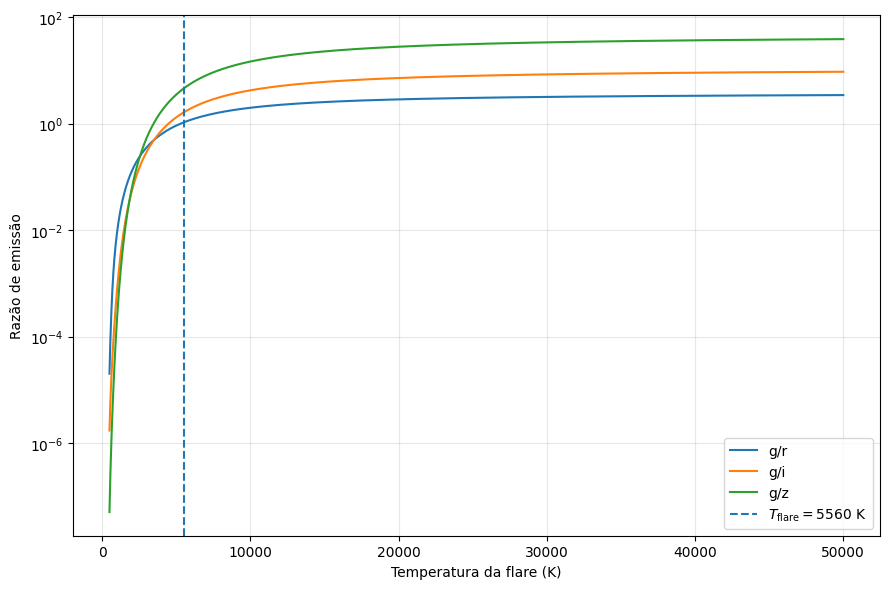

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import trapezoid


# ============================================================
# 1. CONSTANTES FÍSICAS
# ============================================================

h = 6.62607015e-34       # Constante de Planck [J s]
c = 2.99792458e8         # Velocidade da luz [m/s]
k_B = 1.380649e-23       # Constante de Boltzmann [J/K]


# ============================================================
# 2. RESPOSTA ESPECTRAL DO SPARC4
# ============================================================

tf = pd.read_csv(
    "data/sparc4_spectral_response.csv"
)

nm = np.asarray(
    tf["Wavelength (nm)"],
    dtype=float
)

R_g = np.asarray(
    tf["Channel g (%)"],
    dtype=float
) / 100.0

R_r = np.asarray(
    tf["Channel r (%)"],
    dtype=float
) / 100.0

R_i = np.asarray(
    tf["Channel i (%)"],
    dtype=float
) / 100.0

R_z = np.asarray(
    tf["Channel z (%)"],
    dtype=float
) / 100.0


# ============================================================
# 3. TEMPERATURA EFETIVA DA ESTRELA
# ============================================================

Teff = 3700.0   # K


# ============================================================
# 4. CRIAÇÃO DA GRADE DE CADA CANAL
# ============================================================

def make_grid(wavelength, response, n=500):
    """
    Cria uma grade uniforme de comprimento de onda
    para cada canal e interpola sua resposta espectral.
    """

    mask = (
        np.isfinite(wavelength)
        & np.isfinite(response)
        & (response > 0)
    )

    wmin = wavelength[mask].min()
    wmax = wavelength[mask].max()

    wavelength_grid = np.linspace(
        wmin,
        wmax,
        n
    )

    response_grid = np.interp(
        wavelength_grid,
        wavelength,
        response
    )

    return wavelength_grid, response_grid


wv_g, rsp_g = make_grid(nm, R_g)
wv_r, rsp_r = make_grid(nm, R_r)
wv_i, rsp_i = make_grid(nm, R_i)
wv_z, rsp_z = make_grid(nm, R_z)


print("Grades espectrais criadas.")


# ============================================================
# 5. LEI DE PLANCK
# ============================================================

def planck_lambda(T, wavelength_m):
    """
    Lei de Planck em comprimento de onda:

                    2 h c²
    B_lambda = ------------------------
               lambda^5 [exp(x) - 1]

    onde:

                   h c
    x = -------------------------
            lambda k_B T

    Parâmetros
    ----------
    T : array-like
        Temperatura [K]

    wavelength_m : array-like
        Comprimento de onda [m]

    Retorno
    -------
    B : ndarray
        Intensidade espectral.
    """

    T = np.asarray(
        T,
        dtype=float
    )

    wavelength_m = np.asarray(
        wavelength_m,
        dtype=float
    )

    x = (
        h * c
        /
        (
            wavelength_m[None, :]
            * k_B
            * T[:, None]
        )
    )

    B = (
        2.0 * h * c**2
        /
        (
            wavelength_m[None, :]**5
            *
            np.expm1(x)
        )
    )

    return B


# ============================================================
# 6. FUNÇÃO PARA UMA ÚNICA TEMPERATURA
# ============================================================

def band_flux_single(T, wavelength_nm, response):
    """
    Integra B_lambda(T) * resposta espectral
    para uma temperatura específica.
    """

    wavelength_m = wavelength_nm * 1e-9

    B = (
        2.0 * h * c**2
        /
        (
            wavelength_m**5
            *
            np.expm1(
                h * c
                /
                (
                    wavelength_m
                    * k_B
                    * T
                )
            )
        )
    )

    return trapezoid(
        B * response,
        wavelength_m
    )


# ============================================================
# 7. EMISSÃO DA ESTRELA QUIESCENTE
# ============================================================

print("Calculando emissão da estrela...")

Bstar_g = band_flux_single(
    Teff,
    wv_g,
    rsp_g
)

Bstar_r = band_flux_single(
    Teff,
    wv_r,
    rsp_r
)

Bstar_i = band_flux_single(
    Teff,
    wv_i,
    rsp_i
)

Bstar_z = band_flux_single(
    Teff,
    wv_z,
    rsp_z
)

print("Emissão da estrela calculada.")


# ============================================================
# 8. AMPLITUDES OBSERVADAS DA FLARE
# ============================================================

amp_g = 0.201469
amp_r = 0.096316
amp_i = 0.060511
amp_z = 0.061613


print("\n==============================================")
print("AMPLITUDES DA FLARE")
print("==============================================")

print(f"g = {amp_g:.6f}")
print(f"r = {amp_r:.6f}")
print(f"i = {amp_i:.6f}")
print(f"z = {amp_z:.6f}")


# ============================================================
# 9. FLUXO EXCEDENTE DA FLARE
#
# A amplitude é:
#
#       Delta F
#       -------
#         F0
#
# Logo, o excesso de emissão é proporcional a:
#
#       Delta F_X ~ (Delta F/F0)_X * F0_X
#
# ============================================================

Fflare_g_obs = (
    amp_g * Bstar_g
)

Fflare_r_obs = (
    amp_r * Bstar_r
)

Fflare_i_obs = (
    amp_i * Bstar_i
)

Fflare_z_obs = (
    amp_z * Bstar_z
)


# ============================================================
# 10. CORES OBSERVADAS DA FLARE
# ============================================================

R_gr_obs = (
    Fflare_g_obs
    /
    Fflare_r_obs
)

R_gi_obs = (
    Fflare_g_obs
    /
    Fflare_i_obs
)

R_gz_obs = (
    Fflare_g_obs
    /
    Fflare_z_obs
)

R_ri_obs = (
    Fflare_r_obs
    /
    Fflare_i_obs
)

R_rz_obs = (
    Fflare_r_obs
    /
    Fflare_z_obs
)

R_iz_obs = (
    Fflare_i_obs
    /
    Fflare_z_obs
)


print("\n==============================================")
print("CORES OBSERVADAS DA FLARE")
print("==============================================")

print(f"g/r = {R_gr_obs:.6f}")
print(f"g/i = {R_gi_obs:.6f}")
print(f"g/z = {R_gz_obs:.6f}")
print(f"r/i = {R_ri_obs:.6f}")
print(f"r/z = {R_rz_obs:.6f}")
print(f"i/z = {R_iz_obs:.6f}")


# ============================================================
# 11. GRADE DE TEMPERATURAS
#
# Howard et al.:
#
#       500 K -> 50.000 K
#
# ============================================================

T_grid = np.linspace(
    500.0,
    50000.0,
    5000
)


print("\nNúmero de temperaturas:", len(T_grid))


# ============================================================
# 12. FUNÇÃO VETORIZADA PARA TODAS AS TEMPERATURAS
# ============================================================

def band_flux_grid(
    T_grid,
    wavelength_nm,
    response
):
    """
    Calcula a emissão integrada para TODAS
    as temperaturas da grade simultaneamente.
    """

    wavelength_m = (
        wavelength_nm * 1e-9
    )

    # --------------------------------------------------------
    # Matriz x:
    #
    # linhas      -> temperaturas
    # colunas     -> comprimentos de onda
    # --------------------------------------------------------

    x = (
        h * c
        /
        (
            wavelength_m[None, :]
            *
            k_B
            *
            T_grid[:, None]
        )
    )

    # --------------------------------------------------------
    # Lei de Planck
    # --------------------------------------------------------

    B = (
        2.0 * h * c**2
        /
        (
            wavelength_m[None, :]**5
            *
            np.expm1(x)
        )
    )

    # --------------------------------------------------------
    # Integração
    # --------------------------------------------------------

    return trapezoid(
        B * response[None, :],
        wavelength_m,
        axis=1
    )


# ============================================================
# 13. CALCULAR I_X(T)
# ============================================================

print("\n==============================================")
print("CALCULANDO R(T)")
print("==============================================")

print("Calculando banda g...")

I_g = band_flux_grid(
    T_grid,
    wv_g,
    rsp_g
)

print("Calculando banda r...")

I_r = band_flux_grid(
    T_grid,
    wv_r,
    rsp_r
)

print("Calculando banda i...")

I_i = band_flux_grid(
    T_grid,
    wv_i,
    rsp_i
)

print("Calculando banda z...")

I_z = band_flux_grid(
    T_grid,
    wv_z,
    rsp_z
)

print("Todos os canais calculados.")


# ============================================================
# 14. RELAÇÕES TEÓRICAS R(T)
# ============================================================

R_gr_model = I_g / I_r
R_gi_model = I_g / I_i
R_gz_model = I_g / I_z

R_ri_model = I_r / I_i
R_rz_model = I_r / I_z
R_iz_model = I_i / I_z


# ============================================================
# 15. FUNÇÃO PARA ENCONTRAR T A PARTIR DE R_OBS
# ============================================================

def get_temperature(
    R_obs,
    R_model,
    T_grid
):
    """
    Determina a temperatura cuja razão teórica
    mais se aproxima da razão observada.
    """

    difference = np.abs(
        R_model - R_obs
    )

    idx = np.nanargmin(
        difference
    )

    return (
        T_grid[idx],
        difference[idx]
    )


# ============================================================
# 16. TEMPERATURAS INDIVIDUAIS
# ============================================================

T_gr, err_gr = get_temperature(
    R_gr_obs,
    R_gr_model,
    T_grid
)

T_gi, err_gi = get_temperature(
    R_gi_obs,
    R_gi_model,
    T_grid
)

T_gz, err_gz = get_temperature(
    R_gz_obs,
    R_gz_model,
    T_grid
)

T_ri, err_ri = get_temperature(
    R_ri_obs,
    R_ri_model,
    T_grid
)

T_rz, err_rz = get_temperature(
    R_rz_obs,
    R_rz_model,
    T_grid
)

T_iz, err_iz = get_temperature(
    R_iz_obs,
    R_iz_model,
    T_grid
)


print("\n==============================================")
print("TEMPERATURAS INDIVIDUAIS")
print("==============================================")

print(f"T(g/r) = {T_gr:.1f} K")
print(f"T(g/i) = {T_gi:.1f} K")
print(f"T(g/z) = {T_gz:.1f} K")

print()

print(f"T(r/i) = {T_ri:.1f} K")
print(f"T(r/z) = {T_rz:.1f} K")
print(f"T(i/z) = {T_iz:.1f} K")


# ============================================================
# 17. AJUSTE CONJUNTO
#
# Utilizamos simultaneamente:
#
#       g/r
#       g/i
#       g/z
#
# ============================================================

R_obs = np.array([
    R_gr_obs,
    R_gi_obs,
    R_gz_obs
])

R_model = np.column_stack([
    R_gr_model,
    R_gi_model,
    R_gz_model
])


# ============================================================
# 18. FUNÇÃO DE CUSTO
# ============================================================

# Diferença relativa
relative_difference = (
    R_model - R_obs[None, :]
) / R_obs[None, :]


chi2 = np.sum(
    relative_difference**2,
    axis=1
)


# ============================================================
# 19. MELHOR TEMPERATURA
# ============================================================

idx_best = np.nanargmin(
    chi2
)

T_best = T_grid[
    idx_best
]


print("\n==============================================")
print("TEMPERATURA CONJUNTA")
print("==============================================")

print(
    f"T_flare = {T_best:.1f} K"
)


# ============================================================
# 20. RAZÕES DO MODELO NA TEMPERATURA ENCONTRADA
# ============================================================

R_gr_best = R_gr_model[
    idx_best
]

R_gi_best = R_gi_model[
    idx_best
]

R_gz_best = R_gz_model[
    idx_best
]


print("\n==============================================")
print("OBSERVADO × MODELO")
print("==============================================")

print(
    f"g/r : "
    f"{R_gr_obs:.6f}  |  "
    f"{R_gr_best:.6f}"
)

print(
    f"g/i : "
    f"{R_gi_obs:.6f}  |  "
    f"{R_gi_best:.6f}"
)

print(
    f"g/z : "
    f"{R_gz_obs:.6f}  |  "
    f"{R_gz_best:.6f}"
)


# ============================================================
# 21. EMISSÕES DAS BANDAS NA TEMPERATURA FINAL
# ============================================================

Fg_best = I_g[
    idx_best
]

Fr_best = I_r[
    idx_best
]

Fi_best = I_i[
    idx_best
]

Fz_best = I_z[
    idx_best
]


# ============================================================
# 22. VERIFICAÇÃO DAS RAZÕES
# ============================================================

print("\n==============================================")
print("VERIFICAÇÃO DAS CORES")
print("==============================================")

print(
    "g/r modelo =",
    Fg_best / Fr_best
)

print(
    "g/i modelo =",
    Fg_best / Fi_best
)

print(
    "g/z modelo =",
    Fg_best / Fz_best
)


# ============================================================
# 23. GRÁFICO DAS RELAÇÕES R(T)
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    T_grid,
    R_gr_model,
    label="g/r"
)

plt.plot(
    T_grid,
    R_gi_model,
    label="g/i"
)

plt.plot(
    T_grid,
    R_gz_model,
    label="g/z"
)

plt.axvline(
    T_best,
    linestyle="--",
    label=fr"$T_{{\rm flare}}={T_best:.0f}$ K"
)

plt.xlabel(
    "Temperatura da flare (K)"
)

plt.ylabel(
    "Razão de emissão"
)

plt.yscale("log")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()